# Identifier les cultures depuis l'espace — Sentinel-2 x RPG

**Beauce / Loiret, saison culturale 2023-2024**

Ce notebook documente le raisonnement complet du projet : le problème
business, les données mobilisées, la construction des signatures
temporelles, la classification supervisée et sa validation, et les limites
honnêtes du travail. Le code lourd (téléchargement RPG, requête STAC
Sentinel-2, calcul du cube NDVI, extraction zonale, entraînement) vit dans
`src/` et a déjà été exécuté.

Sommaire :
1. Le problème
2. Les données
3. Signatures temporelles par parcelle
4. Classification et validation spatiale
5. Carte de prédiction
6. Limites et perspectives

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GroupKFold, cross_val_predict

sys.path.insert(0, str(Path("..").resolve() / "src"))

import config
from viz_common import (
    CATEGORICAL_DARK, GRID_COLOR, INK_MUTED, INK_PRIMARY, INK_SECONDARY, SEQUENTIAL_DARK,
    SURFACE, canonical_class_order, class_color_map,
)
from train_classifier import (
    build_features_full_season, build_spatial_blocks, get_date_columns, spatial_split,
)

# Thème sombre.
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.edgecolor": GRID_COLOR, "font.family": "sans-serif",
})
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_dark", SEQUENTIAL_DARK)

## 1. Le problème

L'assolement d'un territoire (quelle surface en blé, en colza, en maïs
cette année) intéresse toute la filière agricole en aval : logistique de
collecte, approvisionnement des industriels, estimation de production,
anticipation des cours. Cette information vient aujourd'hui des
déclarations PAC des exploitants, consolidées dans le **Registre
Parcellaire Graphique (RPG)** — publiées avec plusieurs mois, voire plus
d'un an, de retard.

Le satellite Sentinel-2, lui, observe la même parcelle tous les 5 jours, en
continu, dès la sortie d'hiver. L'hypothèse testée ici : la trajectoire de
végétation d'une parcelle au cours de la saison (mesurée par NDVI) suffit-elle
à elle seule à reconnaître sa culture, sans attendre aucune déclaration ?

On utilise le RPG non pas comme la donnée qu'on cherche à produire plus vite
en réalité, mais comme **vérité terrain pour l'apprentissage supervisé** — on
sait déjà ce qui a été semé en 2023-2024, ce qui permet d'entraîner et de
valider un modèle dont le principe se généraliserait à une saison en cours.

## 2. Les données

- **Sentinel-2 L2A** (Copernicus, libre d'accès), via l'API STAC de
  Microsoft Planetary Computer. Bandes B04 (rouge) / B08 (proche
  infrarouge) pour le NDVI, bande SCL pour masquer nuages/ombres/neige.
  40 scènes utilisées sur la saison, filtrées à moins de 60 % de couverture
  nuageuse, composées en médianes de 15 jours (21 pas de temps,
  novembre 2023 → août 2024).
- **RPG millésime 2024** (dernier publié par l'IGN), région Centre-Val de
  Loire, clippé à une zone de 10×10 km en Beauce, secteur d'Artenay
  (Loiret) — 1656 parcelles agricoles brutes dans l'emprise.

Après filtrage (parcelles < 0,5 ha exclues, buffer négatif de 15 m pour
éviter les pixels de bordure, catégories non-cultures écartées, jachères,
bordures de champ, surfaces non exploitées) et sélection des classes
majoritaires (≥ 50 parcelles), il reste **769 parcelles réparties sur 7
cultures**.

In [2]:
signatures = pd.read_parquet(config.SIGNATURES_PATH)
date_cols = get_date_columns(signatures)
print(f"{len(signatures)} parcelles x {len(date_cols)} pas de temps "
      f"({date_cols[0]} -> {date_cols[-1]})")
signatures.head()

769 parcelles x 21 pas de temps (2023-11-01 -> 2024-08-27)


,code_cultu,surf_parc,x_centroid,y_centroid,culture_label,2023-11-01,2023-11-16,2023-12-01,2023-12-16,2023-12-31,...,2024-04-14,2024-04-29,2024-05-14,2024-05-29,2024-06-13,2024-06-28,2024-07-13,2024-07-28,2024-08-12,2024-08-27
id_parcel,,,,,,,,,,,,,,,,,,,,,
11631907,ORP,18.10,615231.345412,6.773336e+06,Orge de printemps,0.180090,0.180090,0.180090,0.180166,0.211182,...,0.754123,0.889867,0.898900,0.874506,0.699883,0.525259,0.350636,0.176013,0.194030,0.176455
2258769,BTH,28.82,614697.665462,6.773345e+06,Blé tendre d'hiver,0.184735,0.184735,0.196078,0.220182,0.279653,...,0.893385,0.923059,0.921657,0.876414,0.808848,0.591899,0.374951,0.158003,0.172252,0.156535
10772245,MIS,6.98,614995.940775,6.773355e+06,Maïs,0.171591,0.171591,0.175077,0.165912,0.194332,...,0.223992,0.170928,0.169716,0.251396,0.512670,0.482685,0.452701,0.845667,0.772040,0.781280
10785978,ORP,6.25,613581.367372,6.773321e+06,Orge de printemps,0.192765,0.192765,0.192765,0.184533,0.205447,...,0.733112,0.902964,0.889011,0.834630,0.568053,0.440569,0.313085,0.185601,0.184905,0.167564
10769302,BTN,7.65,614050.976532,6.773331e+06,Betterave non fourragère / Bette,0.220484,0.220484,0.204273,0.195460,0.212936,...,0.195463,0.272980,0.559220,0.845460,0.888524,0.874015,0.859505,0.844996,0.732070,0.746429


In [3]:
summary = signatures.groupby(["code_cultu", "culture_label"]).agg(
    n_parcelles=("surf_parc", "count"),
    surface_totale_ha=("surf_parc", "sum"),
).sort_values("n_parcelles", ascending=False)
summary.style.format({"surface_totale_ha": "{:.0f}"})

,,n_parcelles,surface_totale_ha
code_cultu,culture_label,,
BDH,Blé dur d'hiver,202,2259
BTH,Blé tendre d'hiver,160,1866
ORP,Orge de printemps,120,1183
BTN,Betterave non fourragère / Bette,105,1230
CZH,Colza d'hiver,68,693
MIS,Maïs,59,657
ORH,Orge d'hiver,55,436


### Le cube NDVI, concrètement

Avant de parler de "signatures parcellaires", voici à quoi ressemble un seul
pas de temps du cube brut : un composite NDVI de la zone entière, tous
usages du sol confondus (parcelles agricoles, mais aussi routes, bâti,
bosquets). Ce n'est qu'à l'étape suivante qu'on découpe ce raster par
parcelle RPG.

Dimensions : {'time': 21, 'y': 1001, 'x': 1000}
Période : 2023-11-01 -> 2024-08-27


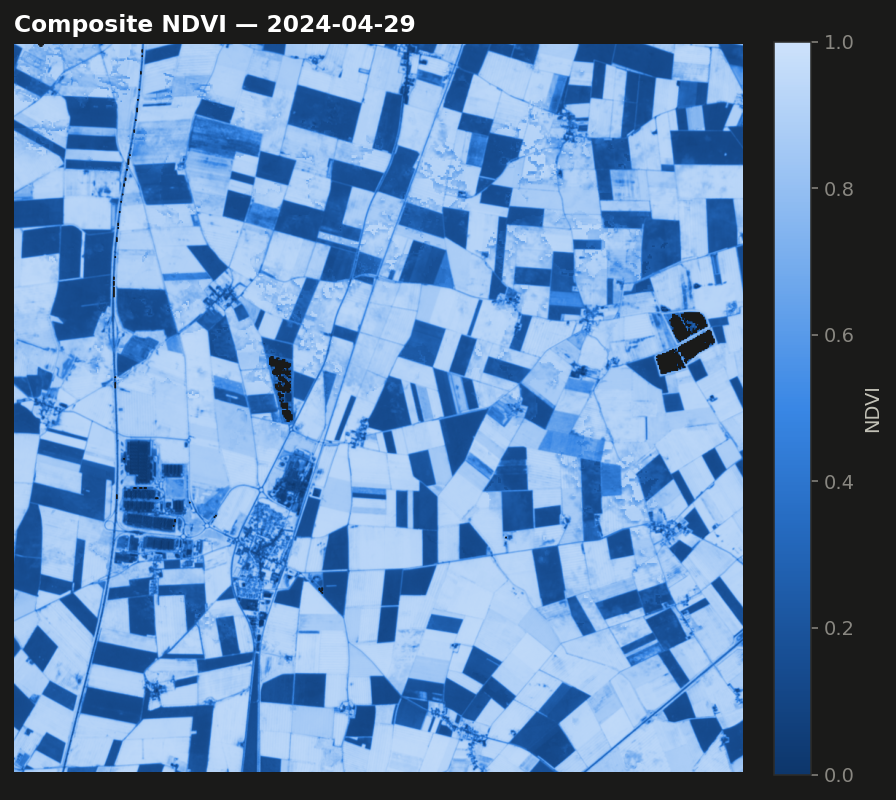

In [4]:
ndvi = xr.open_dataset(config.DATACUBE_PATH)["ndvi"]
print("Dimensions :", dict(ndvi.sizes))
print("Période :", str(ndvi["time"].values[0])[:10], "->", str(ndvi["time"].values[-1])[:10])

date_choice = "2024-04-29"  # pleine montaison des céréales d'hiver
raster = ndvi.sel(time=date_choice, method="nearest")

fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=140)
im = ax.imshow(raster.values, cmap=SEQ_CMAP, vmin=0, vmax=1)
ax.set_title(f"Composite NDVI — {date_choice}", color=INK_PRIMARY, loc="left", fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("NDVI", color=INK_SECONDARY)
cbar.ax.tick_params(colors=INK_MUTED)
fig.tight_layout()
plt.show()

## 3. Signatures temporelles par parcelle

Pour chaque parcelle : rasterisation de son contour (buffer négatif de 15 m
appliqué avant), puis moyenne du NDVI sur ses pixels à chaque pas de temps.
Les trous dus au nuages (certaines fenêtres de 15 jours sont entièrement
couvertes) sont comblés par interpolation linéaire le long du temps, parcelle
par parcelle.

Ci-dessous, quelques parcelles individuelles de chaque culture (en couleur,
semi-transparent) et leur moyenne de classe (en blanc). Le bruit
parcelle-à-parcelle est réel (hétérogénéité de sol, de date de semis, de
pratique), mais la forme d'ensemble émerge nettement.

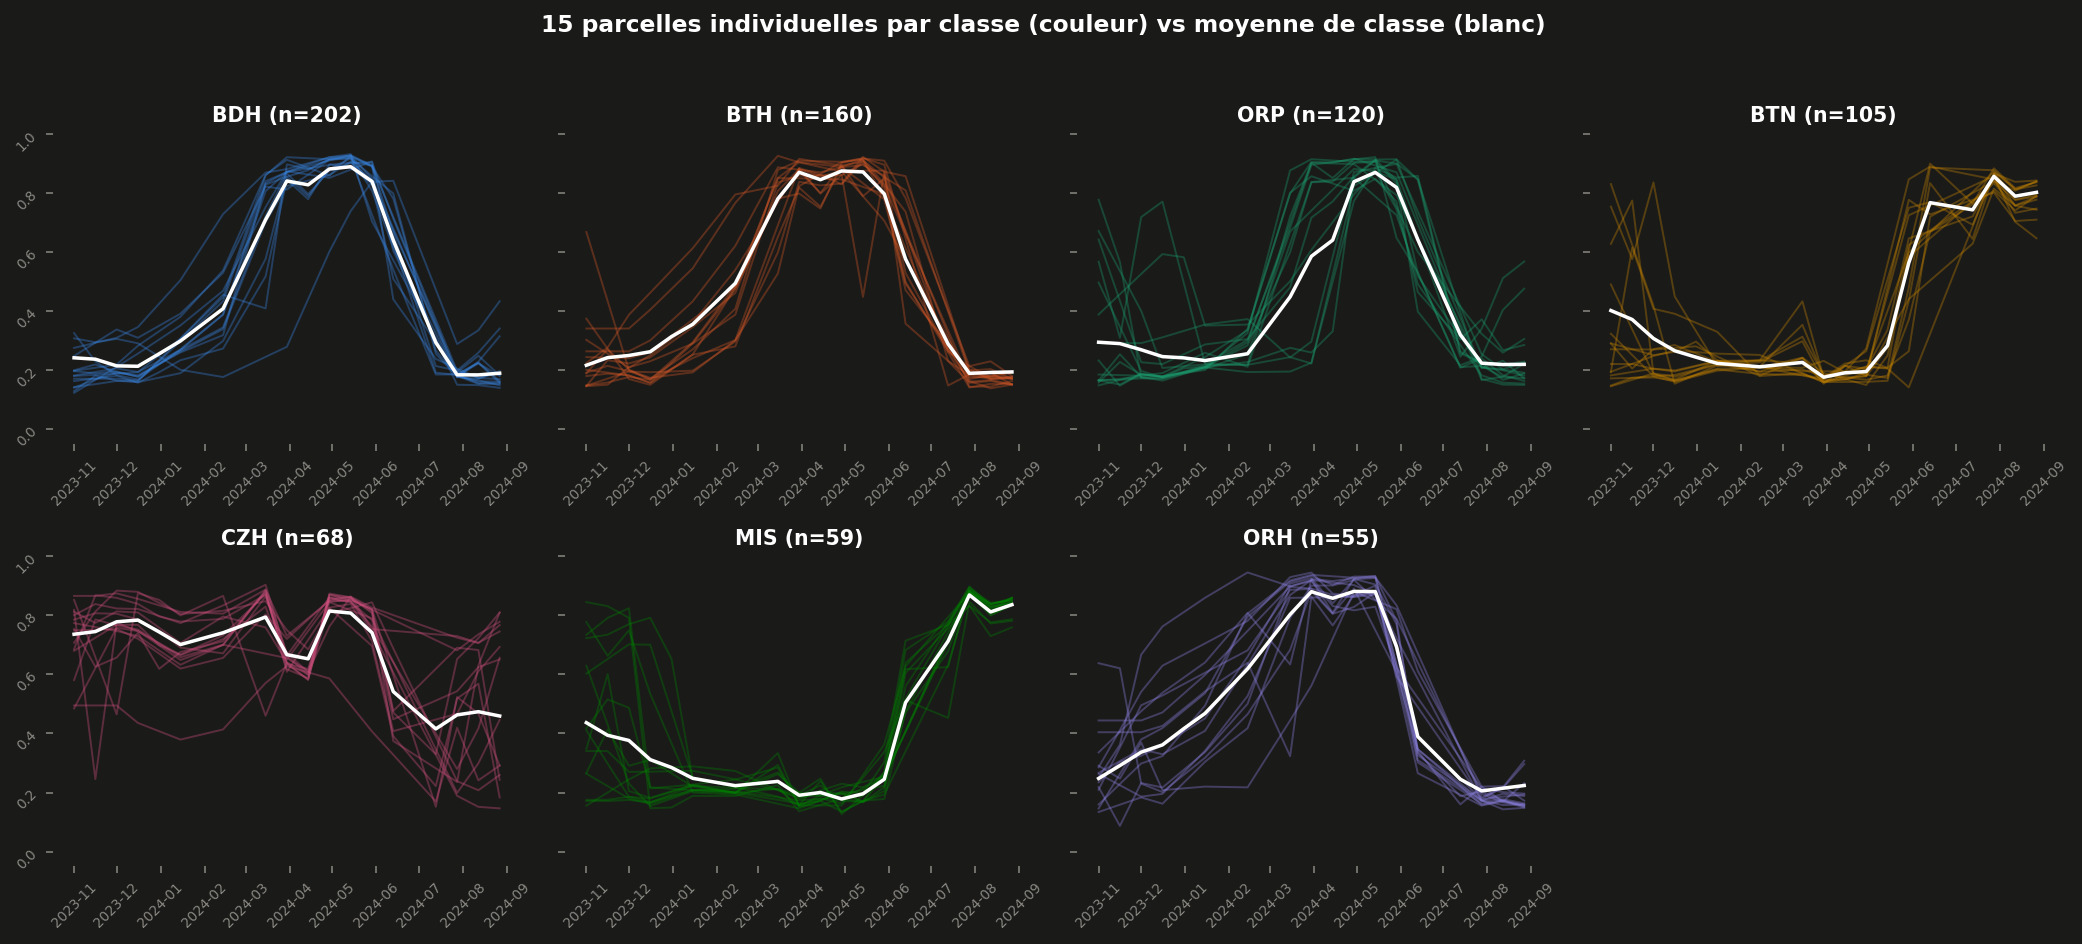

In [5]:
class_order = canonical_class_order(signatures)
color_map = class_color_map(class_order)
dates = pd.to_datetime(date_cols)

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), dpi=140, sharey=True)
axes = axes.flatten()

for ax, code_cultu in zip(axes, class_order):
    sub = signatures[signatures["code_cultu"] == code_cultu]
    sample = sub.sample(min(15, len(sub)), random_state=config.RANDOM_SEED)
    for _, row in sample.iterrows():
        ax.plot(dates, row[date_cols].values, color=color_map[code_cultu], alpha=0.35, linewidth=1)
    ax.plot(dates, sub[date_cols].mean().values, color=INK_PRIMARY, linewidth=1.8)
    ax.set_title(f"{code_cultu} (n={len(sub)})", color=INK_PRIMARY, fontsize=10.5, fontweight="bold")
    ax.set_ylim(-0.05, 1.0)
    ax.tick_params(labelsize=7, rotation=45)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].axis("off")
fig.suptitle(
    "15 parcelles individuelles par classe (couleur) vs moyenne de classe (blanc)",
    color=INK_PRIMARY, fontweight="bold", y=1.03,
)
fig.tight_layout()
plt.show()

### La signature agrégée

![Signatures temporelles NDVI par culture](../outputs/signatures_temporelles.png)

La lecture agronomique, culture par culture :

- **Colza d'hiver (CZH)** — semé fin août, il forme sa rosette dès
  l'automne : c'est la seule culture déjà à NDVI élevé (~0,74) en novembre.
  Légère pause hivernale, reprise de la montaison en mars, floraison jaune
  spectaculaire fin avril (la réflectance des pétales fait parfois
  légèrement fléchir le NDVI à ce moment précis), puis maturation et
  **récolte la plus précoce du groupe**, mi-juillet.
- **Céréales d'hiver — blé dur (BDH), blé tendre (BTH), orge d'hiver
  (ORH)** — semées en octobre-novembre, elles lèvent et tallent lentement
  pendant l'hiver (NDVI modéré, quasi plat), puis montent ensemble et vite
  au printemps (montaison, épiaison), pic autour de fin avril-mi mai,
  sénescence (jaunissement) en juin, **moisson en juillet** : chute brutale
  du NDVI qui les distingue nettement des cultures de printemps.
- **Orge de printemps (ORP)** — semée en février-mars, donc NDVI bas comme
  un sol nu pendant tout l'hiver ; son cycle, plus court que les céréales
  d'hiver, la fait moissonner à peu près au même moment qu'elles malgré un
  départ très différent.
- **Maïs (MIS) et betterave (BTN)** — semés en avril, ils démarrent lentement
  (sol encore nu en mai), puis leur croissance estivale est spectaculaire :
  NDVI encore en hausse fin août dans nos données, parce que leur récolte
  réelle (septembre-novembre) tombe hors de la fenêtre d'observation de ce
  projet. C'est le signal le plus simple à distinguer des céréales d'hiver :
  il est en phase opposée sur toute la saison.

C'est cette diversité de calendriers que le modèle
exploite : aucune information de forme de parcelle, de sol ou de localisation
n'entre dans les features.

## 4. Classification et validation spatiale

**Pourquoi un split spatial et non aléatoire ?** Deux parcelles voisines
partagent souvent le même exploitant, le même sol, le même microclimat et
sont parfois de la même culture. Un split aléatoire classique laisserait
fuiter cette ressemblance entre train et test (une parcelle test
quasi-identique à une parcelle vue à l'entraînement), gonflant
artificiellement le score sans rien dire de la capacité de généralisation
réelle du modèle. On bloque donc la zone en cellules géographiques de 2 km,
chaque cellule restant entièrement du côté train **ou** test.

train    574
test     195
Name: count, dtype: int64
Blocs géographiques : 27 train / 9 test — jamais partagés.


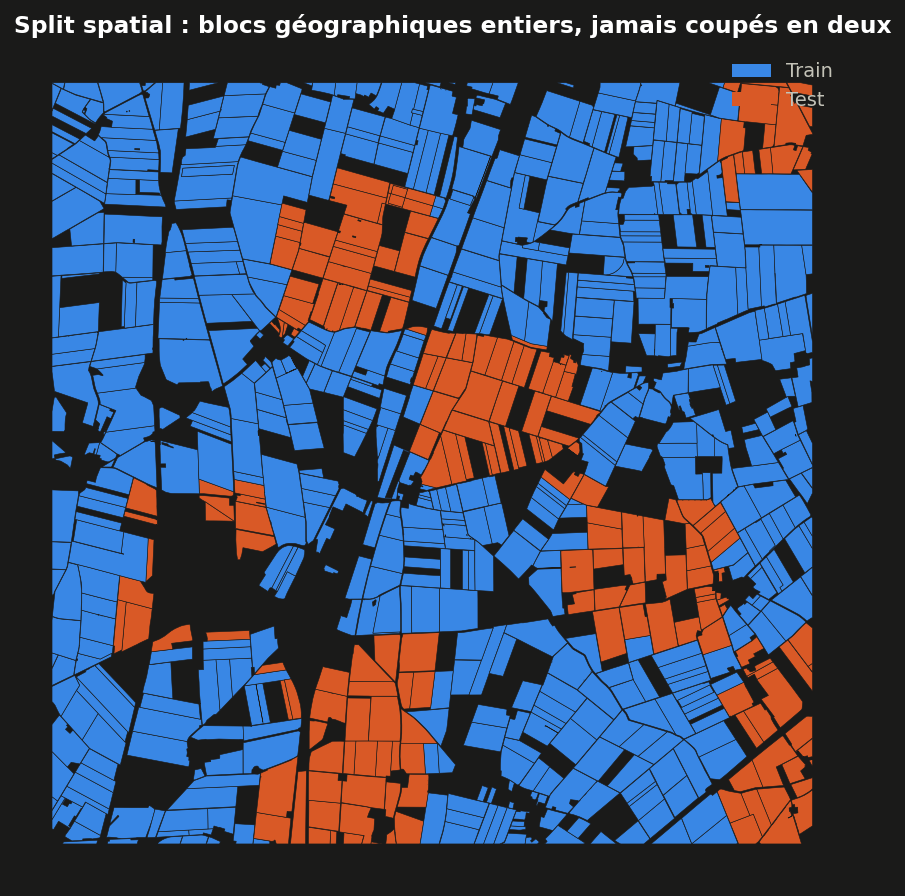

In [6]:
geometry = gpd.read_file(config.PARCELS_GEOMETRY_PATH).set_index("id_parcel")
gdf = gpd.GeoDataFrame(geometry.join(signatures, how="inner"), geometry="geometry", crs=geometry.crs)

groups = build_spatial_blocks(gdf)
X_full = build_features_full_season(gdf, date_cols)
y = gdf["code_cultu"]
train_idx, test_idx = spatial_split(X_full, y, groups)

split_label = pd.Series("train", index=gdf.index)
split_label.iloc[test_idx] = "test"
print(split_label.value_counts())
print(f"Blocs géographiques : {len(np.unique(groups[train_idx]))} train / "
      f"{len(np.unique(groups[test_idx]))} test — jamais partagés.")

fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=140)
colors = split_label.map({"train": CATEGORICAL_DARK[0], "test": CATEGORICAL_DARK[1]})
gdf.plot(ax=ax, color=colors, edgecolor=SURFACE, linewidth=0.3)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Split spatial : blocs géographiques entiers, jamais coupés en deux",
             color=INK_PRIMARY, loc="left", fontweight="bold")
ax.legend(
    handles=[Patch(facecolor=CATEGORICAL_DARK[0], label="Train"),
             Patch(facecolor=CATEGORICAL_DARK[1], label="Test")],
    loc="upper right", frameon=False, labelcolor=INK_SECONDARY,
)
fig.tight_layout()
plt.show()

**Modèle** : RandomForest (300 arbres, `class_weight="balanced"` pour
compenser le déséquilibre 55-202 parcelles/classe), comparé à un
HistGradientBoosting. Les deux se valent en validation croisée spatiale
(GroupKFold, 5 blocs disjoints) ; RandomForest est retenu pour sa simplicité
et son interprétabilité.

| Modèle | Accuracy | F1 macro |
|---|---|---|
| RandomForest | 76.5 % ± 4.0 | 79.2 % ± 3.3 |
| HistGradientBoosting | 75.6 % ± 2.9 | 78.1 % ± 2.9 |

Le tableau ci-dessus moyenne le F1 macro par fold (utile pour comparer les
modèles). Pour le diagnostic par classe qui suit (matrice de confusion,
rapport ci-dessous), on poole plutôt les prédictions hors-échantillon des
5 folds sur les 769 parcelles — plus robuste qu'un split unique sur une
classe à faible effectif comme l'orge d'hiver (55 parcelles au total).

In [7]:
cv = GroupKFold(n_splits=config.N_CV_FOLDS)
model_cv = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    random_state=config.RANDOM_SEED, n_jobs=-1,
)
y_pred_cv = cross_val_predict(model_cv, X_full, y, groups=groups, cv=cv)

bundle = joblib.load(config.MODEL_OUTPUT_PATH)
class_order_model = bundle["class_order"]
print(classification_report(y, y_pred_cv, labels=class_order_model, zero_division=0))

              precision    recall  f1-score   support

         BDH       0.68      0.73      0.70       202
         BTH       0.60      0.53      0.56       160
         ORP       0.76      0.88      0.82       120
         BTN       0.96      0.90      0.93       105
         CZH       0.99      0.99      0.99        68
         MIS       0.85      0.95      0.90        59
         ORH       0.82      0.56      0.67        55

    accuracy                           0.76       769
   macro avg       0.81      0.79      0.80       769
weighted avg       0.76      0.76      0.76       769



Ce calcul poolé retombe sur un F1 macro de 0.80, cohérent avec le 0.792
moyenné par fold dans le tableau ci-dessus (l'écart tient à la façon
d'agréger pas à un problème de calcul : moyenne de F1 macro par fold vs F1 macro sur les prédictions
poolées). Le split spatial unique introduit
plus haut reste utilisé plus bas pour l'importance des features et la
courbe de performance par date, deux diagnostics qui ont besoin d'un
modèle entraîné une seule fois sur un jeu de test fixe et inspectable.

![Matrice de confusion](../outputs/matrice_confusion.png)

Les confusions ne sont pas aléatoires : le colza (F1 0.99) et la betterave
(0.93), des calendriers bien distincts, sont quasi parfaitement reconnus ;
le maïs suit de près (0.90). Les erreurs se concentrent sur les trois
céréales d'hiver, dont les cycles de croissance se chevauchent fortement :
le blé tendre est le plus confondu (F1 0.56 —> 36 % de ses parcelles
prédites à tort comme blé dur), suivi de l'orge d'hiver (0.67, souvent pris
pour du blé tendre) et du blé dur (0.70). C'est une confusion
agronomiquement logique pas
un défaut de mise en œuvre : le NDVI seul ne porte pas l'information qui
distinguerait un blé tendre d'un blé dur au même stade phénologique.

### Où le modèle regarde-t-il ?

![Importance des features par permutation](../outputs/importance_features.png)

RandomForest est annoncé plus haut pour son interprétabilité, autant le
vérifier plutôt que l'affirmer. L'importance par permutation (baisse
d'accuracy quand une feature est mélangée aléatoirement, calculée sur le
split spatial unique introduit plus haut) fait ressortir un pic nettement au-dessus des autres dates :
**fin mai**, le moment où les céréales d'hiver plafonnent juste avant
sénescence pendant que maïs et betterave sont encore quasiment au ras du
sol —> la date où les calendriers divergent le plus, donc celle qui sépare
le mieux les classes.

Les features dérivées (max, amplitude, date du pic, pente de printemps) n'apportent
quasiment rien de plus que la série brute ; deux sont même légèrement
négatives (permuter la colonne améliore parfois le score par hasard, signe
qu'elle est redondante avec l'information déjà portée par les 21 valeurs
NDVI). Le feature engineering "simple" évoqué dans le plan initial du
projet ne s'est pas avéré nécessaire ici : la série brute portait déjà
l'information.

### À partir de quand peut-on prédire l'assolement ?

![Courbe de performance en fonction de la date](../outputs/courbe_performance_date.png)

L'argument business chiffré : la précision atteignable en ne connaissant la
saison que jusqu'à telle date. 20 % en novembre (quasiment rien à
distinguer), on franchit 50 % fin février, et on atteint un plateau à
**~71-74 % dès la mi-juin**, un mois avant la fin de la fenêtre
d'observation, et plusieurs mois avant que les déclarations PAC ne soient
consolidées et publiées.

Détail méthodologique qui compte : cette courbe part de la matrice NDVI
**non interpolée**, et les trous nuageux sont comblés à chaque coupure
uniquement à partir des observations déjà disponibles à cette date (les NaN
résiduels sont imputés à la médiane du train). Interpoler la saison complète
puis découper aurait injecté des observations futures
dans les modèles de début de saison : trois composites entièrement nuageux
(fin janvier, fin février, fin juin) auraient été reconstruits depuis le
futur.

## 5. Carte de prédiction

![Carte de prédiction des cultures](../outputs/carte_predictions.png)

Cette carte n'utilise pas le split unique ci-dessus : chaque parcelle des
769 est prédite par un modèle qui ne l'a jamais vue à l'entraînement
(validation croisée spatiale sur l'ensemble de la zone), pour donner une
carte d'erreurs honnête sur 100 % des parcelles plutôt que sur les 25 % du
test. Précision hors échantillon : 76,5 %, cohérente avec la validation
croisée ci-dessus. Les erreurs (en rouge) ne sont pas uniformément réparties
dans l'espace, elles se concentrent là où les céréales d'hiver dominent,
cohérent avec la confusion structurelle identifiée dans la matrice de
confusion.

### L'assolement : la question business, littéralement

![Assolement prédit vs réel](../outputs/assolement_pred_vs_reel.png)

Le pitch du projet ne porte pas sur des parcelles individuelles mais sur
**l'assolement**, les surfaces par culture à l'échelle du territoire. En
agrégeant les mêmes prédictions hors échantillon par culture :

- Le **colza** est estimé à **±1 %** près : son calendrier unique le rend
  fiable jusqu'à l'agrégation.
- L'écart absolu moyen est de **15 % par culture**, mais très inégalement
  réparti : les erreurs sont des substitutions internes au bloc céréalier
  (blé tendre sous-estimé de 27 %, orge de printemps surestimée de 25 %).
- Toutes céréales confondues (blés + orges), l'écart tombe à **−0,4 %** :
  le modèle sait dire "c'est une céréale" presque parfaitement, il hésite
  sur *laquelle*.

Pour un acteur qui raisonne en grandes masses (céréales vs industrielles vs
oléagineux), l'estimation est déjà exploitable ; pour distinguer blé tendre
et blé dur, le NDVI seul ne suffit pas, d'autres bandes spectrales ou du
radar seraient nécessaires.

## 6. Limites et perspectives

- **Une seule zone, un seul millésime.** La généralisation à une autre
  région ou une autre année n'est pas démontrée ici.
- **Le RPG est déclaratif** : il contient ses propres erreurs (déclaration
  imprécise, culture dérobée non signalée, parcelle mal dessinée). Une
  partie du "bruit" mesuré pourrait être du bruit d'étiquette, pas une erreur du
  modèle.
- **Les classes rares sont écartées** (pomme de terre, oignon... < 50
  parcelles) : l'assolement complet de la zone n'est pas couvert.
- **La validation spatiale limite, mais n'élimine pas totalement**
  l'autocorrélation spatiale : au sein d'un même bloc de 2 km, des pratiques
  culturales ou des types de sol partagés peuvent subsister.
- **Le cadrage temporel de l'évaluation n'est pas celui du déploiement réel.**
  Train et test partagent ici le même millésime (2023-2024) : le split
  spatial protège de la fuite entre parcelles voisines, pas d'une éventuelle
  spécificité de cette saison (pluviométrie, dates de semis) qui ne se
  reproduirait pas à l'identique l'année suivante. En usage réel on entraînerait sur le millésime N-1
  pour prédire N, un écart plus dur que celui mesuré ici et qui reste à
  quantifier.

Pistes non implémentées pour une suite éventuelle : comparaison NDVI
inter-annuelle (impact d'une sécheresse), détection automatique de la date
de moisson par rupture de pente du NDVI, test de généralisation du modèle
entraîné ici sur une autre zone ou une autre année (ce qui couvrirait aussi
le point temporel ci-dessus).

---

**Sources** : imagerie Copernicus Sentinel-2 (Microsoft Planetary Computer) ;
Registre Parcellaire Graphique © IGN, Licence Ouverte / Open Licence Etalab.
Code sous licence MIT — voir `README.md` et `LICENSE` à la racine du dépôt.